<a href="https://colab.research.google.com/github/Tashfi12/Basic-Deep-Learning-Exercise/blob/main/ANN_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Artificial Neural Network
Breast cancer wisconsin dataset (classification)
Conduct the neural network analysis and improve the model performance.

Target : Malign = 0, Benign =1

In [ ]:
#import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import drive
drive.mount('/drive')

Mounted at /drive


In [ ]:
path = '/drive/My Drive/Colab Notebooks/Datasets/cancer.csv'

In [ ]:
data = pd.read_csv(path)
data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
X = data.drop('Target', axis = 1)
Y = data['Target']

In [ ]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
Y

,Target
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [ ]:
#Malign=0, Benign=1
Y.value_counts()

,count
Target,
1,357
0,212


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 2)

print("X_train shape", X_train.shape)
print("X_test shape", X_test.shape)
print("Y_train shape", Y_train.shape)
print("Y_test shape", Y_test.shape)

X_train shape (426, 30)
X_test shape (143, 30)
Y_train shape (426,)
Y_test shape (143,)


In [ ]:
#Normalization
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Building the sequential model
from keras.models import Sequential
from keras.layers import Dense, Input
model = Sequential()
model.add(Input(shape = (30,))) # Input Layer
model.add(Dense(100, activation = 'relu')) # First Dense Layer
model.add(Dense(100, activation = 'relu')) # Second Dense Layer
model.add(Dense(1, activation = 'sigmoid')) # Output Layer

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 100)            │         3,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,301 (51.96 KB)

 Trainable params: 13,301 (51.96 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compiling the sequential model
model.compile(loss = 'binary_crossentropy', metrics = ['accuracy'], optimizer = 'adam')

In [ ]:
# Training the model for 10 epochs
history = model.fit(X_train, Y_train, epochs = 10, batch_size=16,
                    validation_data = (X_test, Y_test))

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7277 - loss: 0.6232 - val_accuracy: 0.8462 - val_loss: 0.5315
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8991 - loss: 0.4392 - val_accuracy: 0.8811 - val_loss: 0.3305
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8944 - loss: 0.2844 - val_accuracy: 0.9021 - val_loss: 0.2309
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9343 - loss: 0.1958 - val_accuracy: 0.9091 - val_loss: 0.1790
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9390 - loss: 0.1625 - val_accuracy: 0.9091 - val_loss: 0.2206
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9507 - loss: 0.1489 - val_accuracy: 0.9161 - val_loss: 0.1410
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9601 - loss: 0.1202 - val_accuracy: 0.9371 - val_loss: 0.1171
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9460 - loss: 0.1451 - val_accuracy: 0.9510 - val_loss

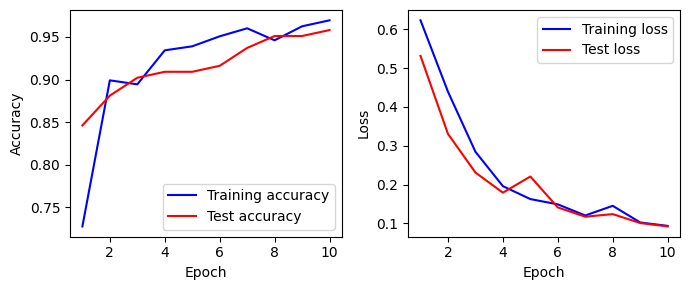

In [ ]:
import matplotlib.pyplot as plt
acc2 = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss2 = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc2) + 1)

# Creating Subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7,3))
axes[0].plot(epochs, acc2, 'b', label='Training accuracy')
axes[0].plot(epochs, val_acc, 'r', label='Test accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(epochs, loss2, 'b', label='Training loss')
axes[1].plot(epochs, val_loss, 'r', label='Test loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout() # Adjusting Layout for Better Spacing

plt.show() # Display the Figure

In [ ]:
# Converting Values
pred = model.predict(X_test)
y_pred = (pred > 0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.91      0.94        56
           1       0.95      0.99      0.97        87

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.96       143
weighted avg       0.96      0.96      0.96       143



In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, y_pred)
print(cm)

[[51  5]
 [ 1 86]]


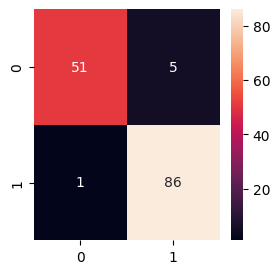

In [ ]:
import seaborn as sns
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True)
plt.show()

Improving Performance

In [ ]:
# Training the model for 10 epochs
history_1 = model.fit(X_train, Y_train, epochs = 20, batch_size=21,
                    validation_data = (X_test, Y_test))

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9789 - loss: 0.0870 - val_accuracy: 0.9441 - val_loss: 0.0978
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9765 - loss: 0.0804 - val_accuracy: 0.9510 - val_loss: 0.0890
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9765 - loss: 0.0774 - val_accuracy: 0.9650 - val_loss: 0.0797
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9789 - loss: 0.0764 - val_accuracy: 0.9650 - val_loss: 0.0773
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9789 - loss: 0.0708 - val_accuracy: 0.9720 - val_loss: 0.0754
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9789 - loss: 0.0731 - val_accuracy: 0.9650 - val_loss: 0.0735
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9742 - loss: 0.0676 - val_accuracy: 0.9790 - val_loss: 0.0714
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9836 - loss: 0.0655 - val_accuracy: 0.9580 - val_loss:

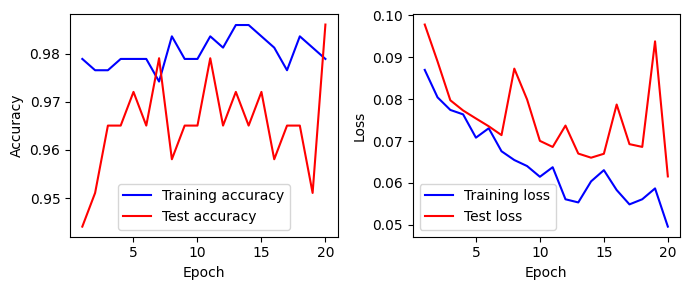

In [ ]:
import matplotlib.pyplot as plt
acc2 = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']
loss2 = history_1.history['loss']
val_loss = history_1.history['val_loss']

epochs = range(1, len(acc2) + 1)

# Creating Subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7,3))
axes[0].plot(epochs, acc2, 'b', label='Training accuracy')
axes[0].plot(epochs, val_acc, 'r', label='Test accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(epochs, loss2, 'b', label='Training loss')
axes[1].plot(epochs, val_loss, 'r', label='Test loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout() # Adjusting Layout for Better Spacing

plt.show() # Display the Figure

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Input

from keras import initializers
from keras import regularizers

model = Sequential()
model.add(Input(shape = (30,))) # Input Layer
model.add(Dense(100, activation = 'relu',
                kernel_initializer = 'he_normal',
                kernel_regularizer = regularizers.l2(0.01)))
model.add(Dense(100, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

In [ ]:
model.compile(loss = 'binary_crossentropy', metrics = ['accuracy'], optimizer = 'adam')
history_2 = model.fit(X_train, Y_train, epochs = 20, batch_size=21,
                    validation_data = (X_test, Y_test))

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5610 - loss: 2.5492 - val_accuracy: 0.7692 - val_loss: 2.3687
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8732 - loss: 2.2270 - val_accuracy: 0.8811 - val_loss: 2.0473
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9178 - loss: 1.9136 - val_accuracy: 0.9021 - val_loss: 1.7375
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8944 - loss: 1.6356 - val_accuracy: 0.9161 - val_loss: 1.4964
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9225 - loss: 1.4142 - val_accuracy: 0.9161 - val_loss: 1.3180
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9390 - loss: 1.2503 - val_accuracy: 0.9371 - val_loss: 1.1788
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9460 - loss: 1.1114 - val_accuracy: 0.9371 - val_loss: 1.0499
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9577 - loss: 0.9924 - val_accuracy: 0.9510 - val_loss

In [ ]:
from keras.layers import Dropout
from keras.callbacks import EarlyStopping

model = Sequential()
model.add(Input(shape = (30,))) # Input Layer
model.add(Dense(100, activation = 'relu',
                kernel_initializer = 'he_normal',
                kernel_regularizer = regularizers.l2(0.01)))
model.add(Dense(100, activation = 'relu'))
model.add(Dropout(rate = 0.2))
model.add(Dense(1, activation = 'sigmoid'))

In [ ]:
model.compile(loss = 'binary_crossentropy', metrics = ['accuracy'], optimizer = 'adam')
history_3 = model.fit(X_train, Y_train, epochs = 10, batch_size=21,
                    validation_data = (X_test, Y_test),
                      callbacks=[EarlyStopping(patience = 2)])

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9624 - loss: 0.7672 - val_accuracy: 0.9510 - val_loss: 0.7222
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9671 - loss: 0.6834 - val_accuracy: 0.9720 - val_loss: 0.6421
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9648 - loss: 0.6248 - val_accuracy: 0.9580 - val_loss: 0.5885
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9695 - loss: 0.5755 - val_accuracy: 0.9580 - val_loss: 0.5483
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9718 - loss: 0.5259 - val_accuracy: 0.9790 - val_loss: 0.4972
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9765 - loss: 0.4825 - val_accuracy: 0.9790 - val_loss: 0.4616
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9836 - loss: 0.4410 - val_accuracy: 0.9790 - val_loss: 0.4287
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9765 - loss: 0.4175 - val_accuracy: 0.9860 - val_loss

Keras Tuner

In [ ]:
!pip install keras-tuner

In [ ]:
import tensorflow as tf

from tensorflow import keras
from keras_tuner import RandomSearch

def build_model(hp):
    model = keras.Sequential()
    # Fisrt hidden layer
    model.add(keras.layers.Dense(
        units=hp.Int('units_1', min_value=32, max_value=512, step=32),
        activation=hp.Choice('activation_1', values=['relu', 'tanh', 'sigmoid']),
        input_shape=(X_train.shape[1],)
    ))

    # Tune the second hidden layer
    model.add(keras.layers.Dense(
        units=hp.Int('units_2', min_value=32, max_value=512, step=32),
        activation=hp.Choice('activation_2', values=['relu', 'tanh', 'sigmoid'])
    ))

    # Output layer for binary classification
    model.add(keras.layers.Dense(1, activation='sigmoid'))

    # Complile the model with a tunable optimizer
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

    tuner = RandomSearch(
        build_model,
        objective='val_accuracy',
        max_trials=10,
        executions_per_trial=3,
        directory='my_dir',
        project_name='hyperparam_tuning'
    )

    # Perform the search
    tuner.search(X_train, Y_train, epochs=10, batch_size=32,
                 validation_data=(X_test, Y_test))

In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters:")
print(best_hp.values)

loss, accuracy = best_model.evaluate(X_test, Y_test)

In [ ]:
best_model.summary()

In [ ]:
#showing 10 best trails
results = tuner.results_summary()